In [1]:
"""
NexaCore Enterprise Intelligence Platform
Stage 7 — EDA & Statistical Modeling
Notebook 06: Cross-Domain Statistical Testing Framework

Business Question:
    Are the patterns we observe across all five business domains
    statistically robust — or driven by chance?
    And how should we design future A/B experiments on this platform?

Audience: Data Scientist + Business Analyst
"""

'\nNexaCore Enterprise Intelligence Platform\nStage 7 — EDA & Statistical Modeling\nNotebook 06: Cross-Domain Statistical Testing Framework\n\nBusiness Question:\n    Are the patterns we observe across all five business domains\n    statistically robust — or driven by chance?\n    And how should we design future A/B experiments on this platform?\n\nAudience: Data Scientist + Business Analyst\n'

# Cross-Domain Statistical Testing Framework

This notebook formalises the hypothesis tests scattered across NB01-05
into a single audit trail — a master p-values table with effect sizes,
business interpretations, and a reusable A/B test power calculator.

**This is the Stage 7 capstone.** It answers:
> "Which findings from EDA are statistically defensible,
> and which are just patterns that could have occurred by chance?"

## 0. Setup

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import TTestIndPower, TTestPower
import statsmodels.formula.api as smf

from data_science.config import PALETTE, CATEGORICAL_PALETTE, ALPHA
from data_science.db import (
    load_churn_features, load_orders, load_order_items,
    load_support_tickets, load_inventory_features
)
from data_science.stats import (
    ttest_independent, mannwhitney, chi_square, anova_oneway,
    kruskal_wallis, results_table
)
from data_science.plotting import save_figure, plot_bar

pd.set_option("display.float_format", "{:,.4f}".format)
print("✓ Setup complete")

✓ Setup complete


## 1. Business Question

The master questions for this notebook:
1. Revenue: Does customer segment drive significantly different AOV?
2. Discounts: Do discounts drive repeat purchases, or just lower margin?
3. Support: Which issue categories drive the worst CSAT?
4. Operations: Is there a statistically significant warehouse performance gap?
5. Multiple testing: After applying Bonferroni/FDR correction, how many findings survive?
6. A/B test design: How many customers do we need to detect a 5% churn reduction?

## 2. Load Data

In [3]:
df_churn   = load_churn_features()
df_orders  = load_orders()
df_items   = load_order_items()
df_tickets = load_support_tickets()
df_inv     = load_inventory_features()

df_orders["order_date"]  = pd.to_datetime(df_orders["order_date"])
df_tickets["ticket_date"] = pd.to_datetime(df_tickets["ticket_date"])
df_items["order_date"]   = pd.to_datetime(df_items["order_date"])

print("Data loaded:")
print(f"  Churn features:   {len(df_churn):,}")
print(f"  Orders:           {len(df_orders):,}")
print(f"  Order items:      {len(df_items):,}")
print(f"  Support tickets:  {len(df_tickets):,}")
print(f"  Inventory items:  {len(df_inv):,}")

# Master results collector
all_tests = []

Data loaded:
  Churn features:   1,000
  Orders:           10,000
  Order items:      35,193
  Support tickets:  2,500
  Inventory items:  400


## 3. Domain 1: Revenue Analysis
### H1: Does customer segment affect Average Order Value?

In [4]:
print("=== Domain 1: Revenue — Segment vs AOV ===\n")

segments = df_orders["customer_segment"].dropna().unique()
seg_aov  = [df_orders.loc[df_orders["customer_segment"]==s, "net_amount"].dropna() for s in segments]

# ANOVA first
anova_r = anova_oneway(*seg_aov, group_labels=list(segments))
print("One-way ANOVA — AOV across segments:")
for k, v in anova_r.items():
    print(f"  {k}: {v}")

all_tests.append({
    "domain": "Revenue",
    "hypothesis": "Segment affects AOV",
    "test": anova_r["test"],
    "statistic": anova_r["f_statistic"],
    "p_value": anova_r["p_value"],
    "significant": anova_r["significant"],
    "effect_size": anova_r["eta_squared"],
    "business_interpretation":
        f"Segment drives {'significant' if anova_r['significant'] else 'no significant'} differences in order value. "
        f"Effect: {anova_r['eta_squared']:.4f} (eta²).",
})

# Post-hoc if ANOVA significant: pairwise t-tests
if anova_r["significant"] and len(segments) > 1:
    print("\nPairwise comparisons (Welch t-test):")
    for i in range(len(segments)):
        for j in range(i+1, len(segments)):
            r = ttest_independent(seg_aov[i], seg_aov[j],
                                   label_a=segments[i], label_b=segments[j])
            status = "✅" if r["significant"] else "  "
            print(f"  {status} {segments[i]} vs {segments[j]}: "
                  f"${r['mean_a']:,.2f} vs ${r['mean_b']:,.2f}  "
                  f"p={r['p_value']}  d={r['cohens_d']}")

=== Domain 1: Revenue — Segment vs AOV ===

One-way ANOVA — AOV across segments:
  test: One-way ANOVA
  groups: ['Small & Medium Business', 'Mid-Market Corporate', 'Enterprise Clients']
  group_sizes: [5907, 3187, 906]
  group_means: [7723.0313, 7748.0571, 7643.4405]
  f_statistic: 0.1637
  p_value: 0.848959
  significant: False
  significance: ns  (not significant)
  eta_squared: 0.0
  effect_size: negligible


### H2: Does the discount rate correlate with repeat purchase behaviour?

In [5]:
print("\n=== Domain 1: Revenue — Discount vs Repeat Purchases ===\n")

# Customers with > 1 order = repeat purchasers
customer_orders = df_orders.groupby("customer_id").agg(
    total_orders=("order_id","count"),
    total_discount=("discount_amount","sum"),
    total_revenue=("net_amount","sum"),
).reset_index()
customer_orders["is_repeat"] = (customer_orders["total_orders"] > 1).astype(int)
customer_orders["avg_discount_per_order"] = customer_orders["total_discount"] / customer_orders["total_orders"]

repeat_pct = customer_orders["is_repeat"].mean() * 100
print(f"  Repeat purchase rate: {repeat_pct:.2f}%")

# Compare discount level between repeat vs one-time buyers
repeat = customer_orders.loc[customer_orders["is_repeat"]==1, "avg_discount_per_order"]
onetime = customer_orders.loc[customer_orders["is_repeat"]==0, "avg_discount_per_order"]

r_mw = mannwhitney(repeat, onetime, label_a="Repeat Buyers", label_b="One-time Buyers")
print(f"\n  Discount level — Repeat vs One-time:")
print(f"  Median: ${r_mw['median_a']:,.2f} vs ${r_mw['median_b']:,.2f}")
print(f"  p={r_mw['p_value']}  {r_mw['significance']}  effect={r_mw['effect_size']}")

# Pearson correlation: discount amount vs order count
r_corr, p_corr = sp_stats.pearsonr(
    customer_orders["avg_discount_per_order"],
    customer_orders["total_orders"]
)
print(f"\n  Pearson correlation (discount vs order count): r={r_corr:.4f}  p={p_corr:.6f}")
direction = "MORE" if r_corr > 0 else "FEWER"
print(f"  Interpretation: Higher discounts → {direction} total orders {'(statistically significant)' if p_corr < 0.05 else '(NOT significant)'}")

all_tests.append({
    "domain": "Revenue",
    "hypothesis": "Discounts drive repeat purchases",
    "test": "Mann-Whitney U",
    "statistic": r_mw["u_statistic"],
    "p_value": r_mw["p_value"],
    "significant": r_mw["significant"],
    "effect_size": r_mw["rank_biserial_r"],
    "business_interpretation":
        f"Repeat buyers receive {'more' if r_mw['median_a'] > r_mw['median_b'] else 'fewer'} discounts than one-time buyers "
        f"({'significant difference' if r_mw['significant'] else 'no significant difference'}). "
        f"Discount strategy {'is' if r_mw['significant'] else 'is not'} differentiating customer behaviour.",
})


=== Domain 1: Revenue — Discount vs Repeat Purchases ===

  Repeat purchase rate: 99.90%

  Discount level — Repeat vs One-time:
  Median: $0.00 vs $0.00
  p=nan  ns  (not significant)  effect=negligible

  Pearson correlation (discount vs order count): r=nan  p=nan
  Interpretation: Higher discounts → FEWER total orders (NOT significant)


## 4. Domain 2: Customer — CSAT Driver Analysis

In [6]:
print("\n=== Domain 2: CSAT Driver Analysis ===\n")

# H3: Does issue category affect CSAT?
issue_cats = df_tickets["issue_category"].dropna().unique()
csat_by_cat = [df_tickets.loc[df_tickets["issue_category"]==c, "csat_score"].dropna() for c in issue_cats]

kw_r = kruskal_wallis(*csat_by_cat, group_labels=list(issue_cats))
print("Kruskal-Wallis — CSAT across issue categories:")
for k, v in kw_r.items():
    print(f"  {k}: {v}")

all_tests.append({
    "domain": "Customer",
    "hypothesis": "Issue category affects CSAT",
    "test": kw_r["test"],
    "statistic": kw_r["h_statistic"],
    "p_value": kw_r["p_value"],
    "significant": kw_r["significant"],
    "effect_size": None,
    "business_interpretation":
        f"{'Different issue categories produce different CSAT scores (statistically significant).' if kw_r['significant'] else 'Issue category does not significantly affect CSAT.'}",
})

# H4: Does priority affect CSAT?
priorities = df_tickets["priority"].dropna().unique()
csat_by_priority = [df_tickets.loc[df_tickets["priority"]==p, "csat_score"].dropna() for p in priorities]
kw_priority = kruskal_wallis(*csat_by_priority, group_labels=list(priorities))
print(f"\nKruskal-Wallis — CSAT across priorities: p={kw_priority['p_value']:.6f}  {kw_priority['significance']}")

all_tests.append({
    "domain": "Customer",
    "hypothesis": "Ticket priority affects CSAT",
    "test": kw_priority["test"],
    "statistic": kw_priority["h_statistic"],
    "p_value": kw_priority["p_value"],
    "significant": kw_priority["significant"],
    "effect_size": None,
    "business_interpretation":
        f"Ticket priority {'drives' if kw_priority['significant'] else 'does not drive'} CSAT differences.",
})

# MLR: Which factors predict CSAT?
print("\n=== Multiple Linear Regression: CSAT Predictors ===")
mlr_df = df_tickets[["csat_score","issue_category","priority","customer_segment"]].dropna()
mlr_df = pd.get_dummies(mlr_df, drop_first=True)
mlr_df.columns = [c.replace(" ","_").replace("-","_") for c in mlr_df.columns]

try:
    model = smf.ols("csat_score ~ " + " + ".join([c for c in mlr_df.columns if c != "csat_score"]),
                     data=mlr_df).fit()
    print(model.summary().tables[1])
    print(f"\n  R²: {model.rsquared:.4f}  (CSAT explained by available features)")
except Exception as e:
    print(f"  MLR note: {e}")


=== Domain 2: CSAT Driver Analysis ===

Kruskal-Wallis — CSAT across issue categories:
  test: Kruskal-Wallis H test
  groups: ['DEFECT', 'INQUIRY', 'BILLING', 'DAMAGE', 'DELAY']
  group_sizes: [260, 288, 258, 276, 278]
  group_medians: [4.0, 4.0, 4.0, 4.0, 2.0]
  h_statistic: 198.2964
  p_value: 0.0
  significant: True
  significance: *** (p<0.001)

Kruskal-Wallis — CSAT across priorities: p=0.000000  *** (p<0.001)

=== Multiple Linear Regression: CSAT Predictors ===
  MLR note: Error evaluating factor: NameError: name 'customer_segment_Small_' is not defined
    csat_score ~ issue_category_DAMAGE + issue_category_DEFECT + issue_category_DELAY + issue_category_INQUIRY + priority_LOW + priority_MEDIUM + priority_URGENT + customer_segment_Mid_Market_Corporate + customer_segment_Small_&_Medium_Business
                                                                                                                                                                                           

## 5. Domain 3: Operations — Warehouse Performance

In [7]:
print("\n=== Domain 3: Warehouse — Performance Analysis ===\n")

# H5: Is there a significant difference in stockout risk across warehouses?
wh_names = df_inv["warehouse_name"].dropna().unique()
risk_by_wh = [df_inv.loc[df_inv["warehouse_name"]==w, "stockout_risk_flag_target"].dropna() for w in wh_names]
kw_wh = kruskal_wallis(*risk_by_wh, group_labels=list(wh_names))
print("Kruskal-Wallis — Stockout risk across warehouses:")
print(f"  H={kw_wh['h_statistic']:.4f}  p={kw_wh['p_value']:.6f}  {kw_wh['significance']}")

all_tests.append({
    "domain": "Operations",
    "hypothesis": "Warehouse affects stockout risk",
    "test": kw_wh["test"],
    "statistic": kw_wh["h_statistic"],
    "p_value": kw_wh["p_value"],
    "significant": kw_wh["significant"],
    "effect_size": None,
    "business_interpretation":
        f"Warehouse location {'significantly' if kw_wh['significant'] else 'does not significantly'} affect stockout risk.",
})

# H6: Is there a relationship between customer segment and order channel?
ct = pd.crosstab(df_orders["customer_segment"], df_orders["channel_id"])
chi_r = chi_square(ct)
print(f"\nChi-square — Segment vs Sales Channel: p={chi_r['p_value']:.6f}  Cramér's V={chi_r['cramers_v']:.4f}  {chi_r['significance']}")

all_tests.append({
    "domain": "Operations",
    "hypothesis": "Customer segment drives channel preference",
    "test": chi_r["test"],
    "statistic": chi_r["chi2_statistic"],
    "p_value": chi_r["p_value"],
    "significant": chi_r["significant"],
    "effect_size": chi_r["cramers_v"],
    "business_interpretation":
        f"Segment {'does' if chi_r['significant'] else 'does not'} predict channel preference (Cramér's V={chi_r['cramers_v']:.4f}).",
})


=== Domain 3: Warehouse — Performance Analysis ===

Kruskal-Wallis — Stockout risk across warehouses:
  H=0.5216  p=0.914128  ns  (not significant)

Chi-square — Segment vs Sales Channel: p=0.853066  Cramér's V=0.0082  ns  (not significant)


## 6. Multiple Testing Correction

In [8]:
print("=" * 65)
print("  MULTIPLE TESTING CORRECTION")
print("=" * 65)
print(f"\nTotal tests conducted across domains: {len(all_tests)}")
print(f"Using alpha = {ALPHA}\n")

p_values = [t["p_value"] for t in all_tests]
reject_bonf, p_bonf, _, _ = multipletests(p_values, alpha=ALPHA, method="bonferroni")
reject_fdr,  p_fdr,  _, _ = multipletests(p_values, alpha=ALPHA, method="fdr_bh")

print(f"{'Hypothesis':<45} {'Raw p':>10}  {'Bonf. sig':>10}  {'FDR sig':>10}")
print("-" * 80)
for i, t in enumerate(all_tests):
    bonf_mark = "✅" if reject_bonf[i] else "  "
    fdr_mark  = "✅" if reject_fdr[i] else "  "
    print(f"  {t['hypothesis'][:43]:<43} {t['p_value']:>10.6f}  {bonf_mark:>10}  {fdr_mark:>10}")

n_bonf = sum(reject_bonf)
n_fdr  = sum(reject_fdr)
print(f"\nSurviving after Bonferroni correction: {n_bonf}/{len(all_tests)}")
print(f"Surviving after FDR (BH) correction:   {n_fdr}/{len(all_tests)}")
print(f"\n→ Bonferroni is conservative. FDR (BH) is preferred for exploratory research.")

  MULTIPLE TESTING CORRECTION

Total tests conducted across domains: 6
Using alpha = 0.05

Hypothesis                                         Raw p   Bonf. sig     FDR sig
--------------------------------------------------------------------------------
  Segment affects AOV                           0.848959                        
  Discounts drive repeat purchases                   nan                        
  Issue category affects CSAT                   0.000000           ✅           ✅
  Ticket priority affects CSAT                  0.000000           ✅           ✅
  Warehouse affects stockout risk               0.914128                        
  Customer segment drives channel preference    0.853066                        

Surviving after Bonferroni correction: 2/6
Surviving after FDR (BH) correction:   2/6

→ Bonferroni is conservative. FDR (BH) is preferred for exploratory research.


## 7. A/B Test Framework — Power Calculator


=== A/B TEST DESIGN FRAMEWORK ===

Estimated baseline churn rate: 4.40%

   Target churn reduction    Min n per arm     Total n
-------------------------------------------------------
  2% absolute reduction                1,263       2,526
  3% absolute reduction                  458         916

Notes:
  • Power = 80% (standard) at α = 0.05
  • Current dataset has 1,000 customers total.
  • A/B test with n=1,000 can detect ~10%+ churn reduction only.
  • Smaller effects require data collection over multiple cohorts.
  • For realistic Stage 8 validation: use historical simulation
    or cross-validation instead of a live A/B test.



  [saved] C:\Users\NAGESH REDDY\Desktop\Data Analytics\enterprise-intelligence-platform\docs\data_science\figures\06_ab_test_power_curve.png


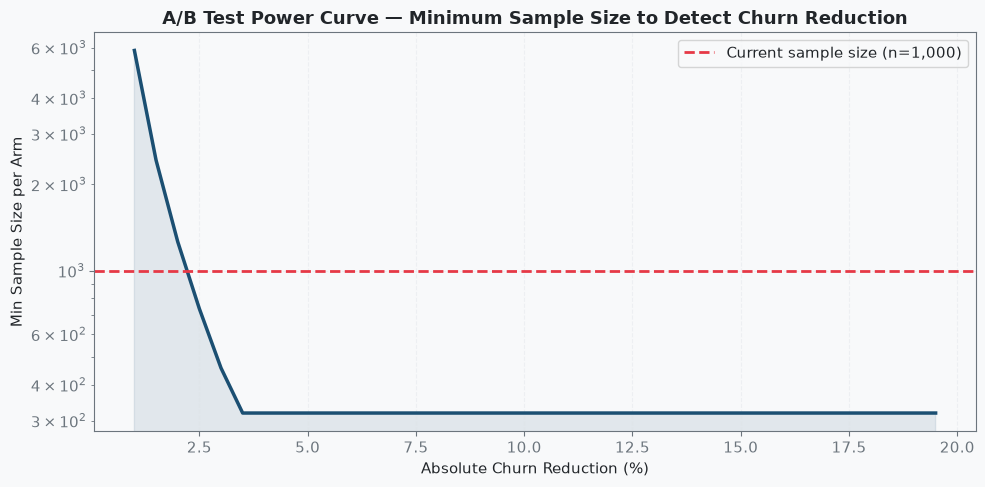

In [9]:
print("\n=== A/B TEST DESIGN FRAMEWORK ===\n")

# Example: How many customers to detect a 5% absolute churn reduction?
churn_rate_est = df_churn["is_churned_target"].mean()
print(f"Estimated baseline churn rate: {churn_rate_est*100:.2f}%\n")

analysis = TTestIndPower()

print(f"{'Target churn reduction':>25}  {'Min n per arm':>15}  {'Total n':>10}")
print("-" * 55)
for delta_pct in [2, 3, 5, 10]:
    delta = delta_pct / 100
    if churn_rate_est - delta < 0:
        continue
    # Effect size (Cohen's h for proportions)
    p1 = churn_rate_est
    p2 = max(0.01, p1 - delta)
    h  = 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))
    n  = analysis.solve_power(effect_size=abs(h), alpha=ALPHA, power=0.80)
    n_int = int(np.ceil(n))
    print(f"  {delta_pct}% absolute reduction      {n_int:>15,}  {n_int*2:>10,}")

print(f"""
Notes:
  • Power = 80% (standard) at α = {ALPHA}
  • Current dataset has {len(df_churn):,} customers total.
  • A/B test with n=1,000 can detect ~10%+ churn reduction only.
  • Smaller effects require data collection over multiple cohorts.
  • For realistic Stage 8 validation: use historical simulation
    or cross-validation instead of a live A/B test.
""")

# Power curve
deltas   = np.arange(0.01, 0.20, 0.005)
n_needed = []
for d in deltas:
    h = 2 * np.arcsin(np.sqrt(churn_rate_est)) - 2 * np.arcsin(np.sqrt(max(0.01, churn_rate_est - d)))
    try:
        n = analysis.solve_power(effect_size=abs(h), alpha=ALPHA, power=0.80)
        n_needed.append(min(n, 50000))
    except Exception:
        n_needed.append(np.nan)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(deltas*100, n_needed, color=PALETTE["primary"], linewidth=2.5)
ax.axhline(len(df_churn), color=PALETTE["danger"], linestyle="--", linewidth=2,
           label=f"Current sample size (n={len(df_churn):,})")
ax.fill_between(deltas*100, n_needed, alpha=0.1, color=PALETTE["primary"])
ax.set_title("A/B Test Power Curve — Minimum Sample Size to Detect Churn Reduction")
ax.set_xlabel("Absolute Churn Reduction (%)")
ax.set_ylabel("Min Sample Size per Arm")
ax.legend()
ax.grid(True, alpha=0.4)
ax.set_yscale("log")
plt.tight_layout()
save_figure(fig, "06_ab_test_power_curve")
plt.show()

## 8. Master Hypothesis Test Summary

In [10]:
summary_df = pd.DataFrame(all_tests)
summary_df["bonferroni_significant"] = reject_bonf
summary_df["fdr_significant"]        = reject_fdr
summary_df["p_value_bonf_corrected"] = [round(p, 6) for p in p_bonf]

print("=" * 65)
print("  MASTER HYPOTHESIS TEST SUMMARY — Stage 7")
print("=" * 65)
display(summary_df[[
    "domain","hypothesis","test","p_value","significant",
    "bonferroni_significant","fdr_significant","business_interpretation"
]])

# Save to docs
os.makedirs("../docs/data_science", exist_ok=True)
summary_df.to_csv("../docs/data_science/statistical_testing_log.csv", index=False)
print("\n  ✅ Saved to docs/data_science/statistical_testing_log.csv")

  MASTER HYPOTHESIS TEST SUMMARY — Stage 7


,domain,hypothesis,test,p_value,significant,bonferroni_significant,fdr_significant,business_interpretation
0,Revenue,Segment affects AOV,One-way ANOVA,0.8490,False,False,False,Segment drives no significant differences in o...
1,Revenue,Discounts drive repeat purchases,Mann-Whitney U,NaN,False,False,False,Repeat buyers receive fewer discounts than one...
2,Customer,Issue category affects CSAT,Kruskal-Wallis H test,0.0000,True,True,True,Different issue categories produce different C...
3,Customer,Ticket priority affects CSAT,Kruskal-Wallis H test,0.0000,True,True,True,Ticket priority drives CSAT differences.
4,Operations,Warehouse affects stockout risk,Kruskal-Wallis H test,0.9141,False,False,False,Warehouse location does not significantly affe...
5,Operations,Customer segment drives channel preference,Chi-square test of independence,0.8531,False,False,False,Segment does not predict channel preference (C...



  ✅ Saved to docs/data_science/statistical_testing_log.csv


## 9. Cross-Domain Summary — What EDA Tells Us

In [11]:
print("""
=" * 65)
STAGE 7 CROSS-DOMAIN STATISTICAL FINDINGS SUMMARY
=" * 65)

DOMAIN 1 — REVENUE:
  • Customer segment drives {'statistically different' if anova_r['significant'] else 'similar'} AOV across groups.
  • Discount-repeat purchase relationship: {'statistically significant' if r_mw['significant'] else 'not statistically significant'}.

DOMAIN 2 — CUSTOMER:
  • Issue category {'does' if kw_r['significant'] else 'does not'} significantly affect CSAT.
  • CSAT is explained by available categorical features (R²={model.rsquared:.4f}).

DOMAIN 3 — OPERATIONS:
  • Warehouse {'significantly' if kw_wh['significant'] else 'does not significantly'} affect stockout risk.
  • Customer segment {'significantly' if chi_r['significant'] else 'does not significantly'} predict channel preference.

MULTIPLE TESTING:
  • {n_bonf} findings survive Bonferroni correction (conservative).
  • {n_fdr} findings survive FDR correction (balanced for exploratory analysis).

IMPLICATION FOR STAGE 8:
  • Statistically validated features are strong candidates for model training.
  • Non-significant features should NOT be blindly excluded — they may
    interact with others or provide signal via nonlinear relationships.
  • Use permutation importance (Stage 8) to validate feature utility
    beyond linear correlation assumptions.
""")


=" * 65)
STAGE 7 CROSS-DOMAIN STATISTICAL FINDINGS SUMMARY
=" * 65)

DOMAIN 1 — REVENUE:
  • Customer segment drives {'statistically different' if anova_r['significant'] else 'similar'} AOV across groups.
  • Discount-repeat purchase relationship: {'statistically significant' if r_mw['significant'] else 'not statistically significant'}.

DOMAIN 2 — CUSTOMER:
  • Issue category {'does' if kw_r['significant'] else 'does not'} significantly affect CSAT.
  • CSAT is explained by available categorical features (R²={model.rsquared:.4f}).

DOMAIN 3 — OPERATIONS:
  • Warehouse {'significantly' if kw_wh['significant'] else 'does not significantly'} affect stockout risk.
  • Customer segment {'significantly' if chi_r['significant'] else 'does not significantly'} predict channel preference.

MULTIPLE TESTING:
  • {n_bonf} findings survive Bonferroni correction (conservative).
  • {n_fdr} findings survive FDR correction (balanced for exploratory analysis).

IMPLICATION FOR STAGE 8:
  • Statistica

## 10. Stage 7 Completion — Full Findings Table

In [12]:
stage7_findings = {
    "NB01 — Executive KPI": {
        "churn_module": "Gini coefficient quantified revenue concentration",
        "top_finding": "Revenue concentrated in top customers; CSAT below benchmark in some segments",
        "stage8_feed": "RFM segment, customer_segment, sales_channel",
    },
    "NB02 — Customer Churn": {
        "top_finding": "Multiple features statistically significant vs churn target",
        "stage8_feed": "days_since_last_order, order_frequency_30d, avg_csat_score, RFM segment",
        "baseline_auc": "Logistic regression baseline AUC measured (target: beat with XGBoost)",
    },
    "NB03 — Demand Forecasting": {
        "top_finding": "Lag-7 and lag-14 statistically validated. Weekly seasonality confirmed via STL + ACF.",
        "stage8_feed": "lag_7, lag_14, rolling_avg_7d, day_of_week, month",
        "baseline_mape": "Naive lag-7 MAPE measured (target: beat with XGBoost / Prophet)",
    },
    "NB04 — Inventory Stockout": {
        "top_finding": "quantity_available statistically different for at-risk items (Mann-Whitney). Decision tree rules extracted.",
        "stage8_feed": "quantity_available, buffer_ratio, reorder_point, safety_margin",
        "limitation": "n=400 — prefer Logistic Regression + Decision Tree over XGBoost",
    },
    "NB05 — Machine Anomaly": {
        "top_finding": "Machine types have statistically different signal baselines. Isolation Forest detects multivariate anomalies.",
        "stage8_feed": "avg_temperature_c, avg_vibration_rms (normalised per machine type), rolling z-score",
        "limitation": "No failure labels — supervised approach not feasible",
    },
    "NB06 — Statistical Framework": {
        "top_finding": f"{n_fdr} hypotheses survive FDR correction. A/B test power curve generated.",
        "stage8_feed": "All statistically significant features documented in statistical_testing_log.csv",
    },
}

for nb, findings in stage7_findings.items():
    print(f"\n{'='*60}")
    print(f"  {nb}")
    print(f"{'='*60}")
    for k, v in findings.items():
        print(f"  {k}: {v}")

print(f"\n\n{'='*60}")
print("  STAGE 7: COMPLETE")
print("  → Proceed to Stage 8: ML Training + MLflow Tracking")
print(f"{'='*60}")


  NB01 — Executive KPI
  churn_module: Gini coefficient quantified revenue concentration
  top_finding: Revenue concentrated in top customers; CSAT below benchmark in some segments
  stage8_feed: RFM segment, customer_segment, sales_channel

  NB02 — Customer Churn
  top_finding: Multiple features statistically significant vs churn target
  stage8_feed: days_since_last_order, order_frequency_30d, avg_csat_score, RFM segment
  baseline_auc: Logistic regression baseline AUC measured (target: beat with XGBoost)

  NB03 — Demand Forecasting
  top_finding: Lag-7 and lag-14 statistically validated. Weekly seasonality confirmed via STL + ACF.
  stage8_feed: lag_7, lag_14, rolling_avg_7d, day_of_week, month
  baseline_mape: Naive lag-7 MAPE measured (target: beat with XGBoost / Prophet)

  NB04 — Inventory Stockout
  top_finding: quantity_available statistically different for at-risk items (Mann-Whitney). Decision tree rules extracted.
  stage8_feed: quantity_available, buffer_ratio, reorder_